# Train Models

In [1]:
import anndata as ad

# Load training data
adata = ad.io.read_h5ad('../data/CellTypistDataset/global.h5ad')

# Filter blood data
adata = adata[adata.obs['Organ'] == 'BLD'].copy()
print(adata)

AnnData object with n_obs × n_vars = 27620 × 36601
    obs: 'Organ', 'Donor', 'Chemistry', 'Cell_category', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype'
    obsm: 'X_umap'


## Preprocessing

In [2]:
import scanpy as sc

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

# Remove mitochondrial, ribosomal and hemoglobin
adata = adata[:, ~adata.var["mt"]].copy()
adata = adata[:, ~adata.var["ribo"]].copy()
adata = adata[:, ~adata.var["hb"]].copy()

In [3]:
# Doublet Detection
sc.pp.scrublet(adata, batch_key="Donor")

## Normalization

In [4]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

## Filtering classes with min_samples

In [ ]:
# Filtering classes with >=150 samples
y = adata.obs['scumi-annotation']

min_samples = 20
class_counts = y.value_counts()
keep_classes = class_counts[class_counts >= min_samples].index

adata = adata[adata.obs["scumi-annotation"].isin(keep_classes)].copy()

## Create train test split

### Find best train test split

In [ ]:
import itertools
import numpy as np
import pandas as pd


TARGET_MIN = 0.20
TARGET_MAX = 0.35
TARGET_CENTER = 0.275
DONOR_COL = "Donor"

donor_counts = adata.obs[DONOR_COL].value_counts().sort_index()
total_cells = donor_counts.sum()

print("Cells pro Donor:")
print(donor_counts)
print("\nGesamtzahl:", total_cells)

# Find best combinations
best_split = None
best_score = np.inf
donors = donor_counts.index.tolist()

# test all splits with exactly 2 donors for testing
for test_donors in itertools.combinations(donors, 2):
    test_cells = donor_counts[list(test_donors)].sum()
    test_ratio = test_cells / total_cells

    if test_ratio > TARGET_MAX or test_ratio < TARGET_MIN:
        continue

    # Score = distance to target middle (absolute value)
    score = abs(test_ratio - TARGET_CENTER)

    if score < best_score:
        train_donors = [
            d for d in donors if d not in test_donors
        ]
        best_score = score
        best_split = {
            "train_donors": train_donors,
            "test_donors": list(test_donors),
            "test_ratio": test_ratio,
            "test_cells": int(test_cells)
        }

print("\nBEST SPLIT")
print("-" * 40)

print("Train Donors:")
print(best_split["train_donors"])

print("\nTest Donors:")
print(best_split["test_donors"])

print(f"\nTest Anteil: {best_split['test_ratio']:.3f}")
print(f"Test Zellen: {best_split['test_cells']}")

# Apply split
train_adata = adata[
    adata.obs[DONOR_COL].isin(best_split["train_donors"])
].copy()

test_adata = adata[
    adata.obs[DONOR_COL].isin(best_split["test_donors"])
].copy()

# Validate best split
print("\nTrain shape:", train_adata.shape)
print("Test shape :", test_adata.shape)

### Apply best split

In [5]:
# All Donors: ['621B', '637C', 'A35', 'A36', 'D496', 'D503']
donor_train = ['637C', 'A35', 'A36', 'D503']
donor_test = ['621B', 'D496']

adata_train = adata[
    adata.obs["Donor"].isin(donor_train)
].copy()

adata_test = adata[
    adata.obs["Donor"].isin(donor_test)
].copy()

# Check split
print(adata_train.obs['Donor'].unique())
print(adata_test.obs['Donor'].unique())

# Prepare Data for training
X_train = adata_train.to_df()
gene_names_train = adata_train.var_names
y_train = adata_train.obs['Manually_curated_celltype']

X_test = adata_test.to_df()
gene_names_train = adata_train.var_names
y_test = adata_test.obs['Manually_curated_celltype']

['A36', 'A35', '637C', 'D503']
Categories (4, object): ['637C', 'A35', 'A36', 'D503']
['621B', 'D496']
Categories (2, object): ['621B', 'D496']


## Model training

### Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
from custom_stopper import CustomStopper

model = LogisticRegression(solver='saga', max_iter=100, random_state=42)

search_space = {
    'C': Real(1, 1e+2, prior='log-uniform'),
    #'penalty': Categorical(['l1', 'l2'])
}

my_stopper = CustomStopper(patience=2, min_delta=0.002, min_iter=4) 

opt = BayesSearchCV(
    estimator=model,
    search_spaces=search_space,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=2,
    verbose=10
)

print("Start BayesSearch with Early Stopping...")
opt.fit(X_train, y_train, callback=my_stopper)

print(f"\nSearch terminated after {len(opt.cv_results_['mean_test_score'])} Iterations.")
print(f"Best hyperparameters: {opt.best_params_}")
print(f"Test-Split Accuracy:  {opt.score(X_test, y_test):.4f}")

Start BayesSearch with Early Stopping...
Fitting 2 folds for each of 1 candidates, totalling 2 fits


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Iter: 1 (Exploration),
Score: 0.8247, Best: 0.8247
Fitting 2 folds for each of 1 candidates, totalling 2 fits


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


KeyboardInterrupt: 

In [6]:
from sklearn.linear_model import LogisticRegression
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
from custom_stopper import CustomStopper

# Model training

model = LogisticRegression(max_iter=100, C=1e-4)

search_space = {
    'C': Real(1e-4, 1e-2, prior='log-uniform'),
    #'penalty': Categorical(['l1', 'l2'])
}

my_stopper = CustomStopper(patience=2, min_delta=0.002, min_iter=4)

opt = BayesSearchCV(
    estimator=model,
    search_spaces=search_space,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=10
)

print("Start BayesSearch with Early Stopping...")
#opt.fit(X_train, y_train, callback=my_stopper)

#print(f"\nSearch terminated after {len(opt.cv_results_['mean_test_score'])} Iterations.")
#print(f"Best hyperparameters: {opt.best_params_}")
#print(f"Test-Split Accuracy:  {opt.score(X_test, y_test):.4f}")

model.fit(X_train, y_train)

print(model.score(X_test, y_test))

Start BayesSearch with Early Stopping...


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.642603550295858


In [7]:
from sklearn.linear_model import LogisticRegression
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
from custom_stopper import CustomStopper

# Model training

model = LogisticRegression(max_iter=1000, C=1e-4)

search_space = {
    'C': Real(1e-4, 1e-2, prior='log-uniform'),
    #'penalty': Categorical(['l1', 'l2'])
}

my_stopper = CustomStopper(patience=2, min_delta=0.002, min_iter=4)

opt = BayesSearchCV(
    estimator=model,
    search_spaces=search_space,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=10
)

print("Start BayesSearch with Early Stopping...")
#opt.fit(X_train, y_train, callback=my_stopper)

#print(f"\nSearch terminated after {len(opt.cv_results_['mean_test_score'])} Iterations.")
#print(f"Best hyperparameters: {opt.best_params_}")
#print(f"Test-Split Accuracy:  {opt.score(X_test, y_test):.4f}")

model.fit(X_train, y_train)

print(model.score(X_test, y_test))

Start BayesSearch with Early Stopping...
0.643249058633674


In [8]:
from sklearn.linear_model import LogisticRegression
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
from custom_stopper import CustomStopper

# Model training

model = LogisticRegression(max_iter=1000, C=1e-2)

search_space = {
    'C': Real(1e-4, 1e-2, prior='log-uniform'),
    #'penalty': Categorical(['l1', 'l2'])
}

my_stopper = CustomStopper(patience=2, min_delta=0.002, min_iter=4)

opt = BayesSearchCV(
    estimator=model,
    search_spaces=search_space,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=10
)

print("Start BayesSearch with Early Stopping...")
#opt.fit(X_train, y_train, callback=my_stopper)

#print(f"\nSearch terminated after {len(opt.cv_results_['mean_test_score'])} Iterations.")
#print(f"Best hyperparameters: {opt.best_params_}")
#print(f"Test-Split Accuracy:  {opt.score(X_test, y_test):.4f}")

model.fit(X_train, y_train)

print(model.score(X_test, y_test))

Start BayesSearch with Early Stopping...
0.8835933297471759


## Code from HPC

In [1]:
import anndata as ad
import scanpy as sc
from sklearn.linear_model import LogisticRegression
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
from custom_stopper import CustomStopper
# For saving results on HPC Cluster
import joblib
import pandas as pd
import os

# Load training data
adata = ad.io.read_h5ad('../data/CellTypistDataset/global_annotated.h5ad')

# Filter blood data
adata = adata[adata.obs['Organ'] == 'BLD'].copy()
print(adata)


# Preprocessing

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

# Remove mitochondrial, ribosomal and hemoglobin
adata = adata[:, ~adata.var["mt"]].copy()
adata = adata[:, ~adata.var["ribo"]].copy()
adata = adata[:, ~adata.var["hb"]].copy()

# Doublet Detection
sc.pp.scrublet(adata, batch_key="Donor")


# Normalization

# Saving count data
adata.layers["counts"] = adata.X.copy()

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

# Filtering Highly variable genes
print('Before filtering highly variable genes ---')
print(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=10000)

# Apply filter
adata = adata[:, adata.var['highly_variable']].copy()

print('After filtering highly variable genes ---')
print(adata)

print('After filtering min_samples ---')
print(adata)

# Create train test split

# All Donors: ['621B', '637C', 'A35', 'A36', 'D496', 'D503']
donor_train = ['637C', 'A35', 'A36', 'D503']
donor_test = ['621B', 'D496']

adata_train = adata[
    adata.obs["Donor"].isin(donor_train)
].copy()

adata_test = adata[
    adata.obs["Donor"].isin(donor_test)
].copy()

# Check split
print(adata_train.obs['Donor'].unique())
print(adata_test.obs['Donor'].unique())

# Prepare Data for training
X_train = adata_train.to_df()
gene_names_train = adata_train.var_names
#y_train = adata_train.obs['Manually_curated_celltype']
y_train = adata_train.obs['scumi-annotation']

X_test = adata_test.to_df()
gene_names_test = adata_test.var_names
##y_test = adata_test.obs['Manually_curated_celltype']
y_test = adata_test.obs['scumi-annotation']

AnnData object with n_obs × n_vars = 27620 × 36473
    obs: 'Organ', 'Donor', 'Chemistry', 'Cell_category', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'scumi-annotation'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scrublet'
    obsm: 'X_umap'
Before filtering highly variable genes ---
AnnData object with n_obs × n_vars = 27620 × 36473
    obs: 'Organ', 'D

### Evaluate different number of genes as features

In [2]:
# Model training

model = LogisticRegression(max_iter=100, C=1e-4)

search_space = {
    'C': Real(1e-4, 1e-2, prior='log-uniform'),
    #'penalty': Categorical(['l1', 'l2'])
}

my_stopper = CustomStopper(patience=2, min_delta=0.002, min_iter=4)

opt = BayesSearchCV(
    estimator=model,
    search_spaces=search_space,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=10
)

print("Start BayesSearch with Early Stopping...")
#opt.fit(X_train, y_train, callback=my_stopper)

#print(f"\nSearch terminated after {len(opt.cv_results_['mean_test_score'])} Iterations.")
#print(f"Best hyperparameters: {opt.best_params_}")
#print(f"Test-Split Accuracy:  {opt.score(X_test, y_test):.4f}")

model.fit(X_train, y_train)

print(model.score(X_test, y_test))

Start BayesSearch with Early Stopping...
0.6126949973103819


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
Full Data
0.642603550295858, 2m12, not enough iterations
20.000 Genes
0.6398063474986552, 56s, not enough iterations
15.000 Genes
0.6293706293706294, 40s, not enough iterations
10.000 Genes
0.6268961807423346, 26s, not enough iterations
5.000 Genes
0.6128025820333513, 18s, not enough iterations
2.000 Genes
0.5775147928994083, 12s, not enough iterations
no limit (1.297 Genes)
0.6126949973103819, 15s

In [3]:
# Model training

model = LogisticRegression(max_iter=1000, C=1e-4)

search_space = {
    'C': Real(1e-4, 1e-2, prior='log-uniform'),
    #'penalty': Categorical(['l1', 'l2'])
}

my_stopper = CustomStopper(patience=2, min_delta=0.002, min_iter=4)

opt = BayesSearchCV(
    estimator=model,
    search_spaces=search_space,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=10
)

print("Start BayesSearch with Early Stopping...")
#opt.fit(X_train, y_train, callback=my_stopper)

#print(f"\nSearch terminated after {len(opt.cv_results_['mean_test_score'])} Iterations.")
#print(f"Best hyperparameters: {opt.best_params_}")
#print(f"Test-Split Accuracy:  {opt.score(X_test, y_test):.4f}")

model.fit(X_train, y_train)

print(model.score(X_test, y_test))

Start BayesSearch with Early Stopping...
0.6125874125874126


In [ ]:
0.6434642280796127
Full Data
0.643249058633674, 9m42
20.000 Genes
0.6390532544378699, 2m29
15.000 Genes
0.6310919849381388, 1m32
10.000 Genes
0.6271113501882732, 1m29
5.000 Genes
0.6128025820333513, 52s
2.000 Genes
0.5764389456697149, 25s
no limit (1.297 Genes)
0.6125874125874126, 36s

In [4]:
# Model training

model = LogisticRegression(max_iter=1000, C=1e-2)

search_space = {
    'C': Real(1e-4, 1e-2, prior='log-uniform'),
    #'penalty': Categorical(['l1', 'l2'])
}

my_stopper = CustomStopper(patience=2, min_delta=0.002, min_iter=4)

opt = BayesSearchCV(
    estimator=model,
    search_spaces=search_space,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=10
)

print("Start BayesSearch with Early Stopping...")
#opt.fit(X_train, y_train, callback=my_stopper)

#print(f"\nSearch terminated after {len(opt.cv_results_['mean_test_score'])} Iterations.")
#print(f"Best hyperparameters: {opt.best_params_}")
#print(f"Test-Split Accuracy:  {opt.score(X_test, y_test):.4f}")

model.fit(X_train, y_train)

print(model.score(X_test, y_test))

Start BayesSearch with Early Stopping...
0.8949973103819258


In [ ]:
0.8841312533620226
Full Data
0.8835933297471759, 2m13
20.000 Genes
0.8892953200645508, 1m39
15.000 Genes
0.8938138784292631, 1m3
10.000 Genes
0.8980096826250672, 42s
5.000 Genes
0.8960731576116191, 25s
2.000 Genes
0.8849919311457773, 17s
no limit (1.297 Genes)
0.8949973103819258, 21s

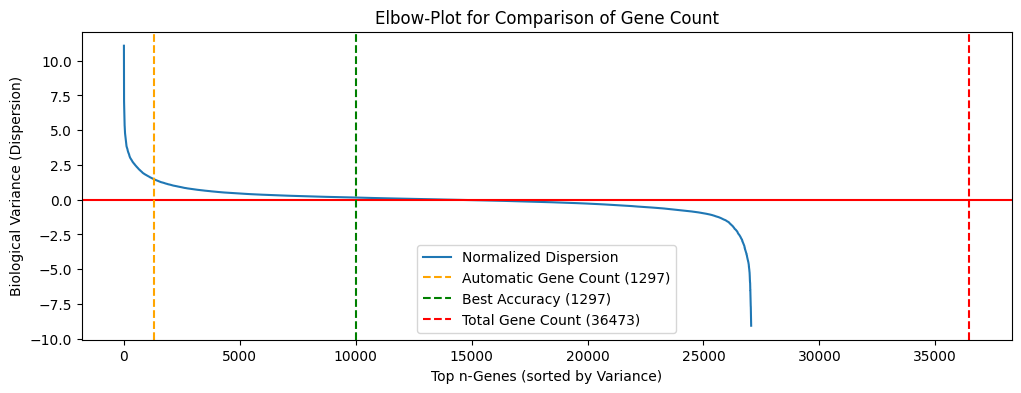

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Sortiere die Dispersionen aller Gene absteigend
dispersions = adata.var['dispersions_norm'].dropna().sort_values(ascending=False).values

plt.figure(figsize=(12, 4))
plt.plot(dispersions, label='Normalized Dispersion')
plt.axhline(y=0, color='red', linestyle='-', label='')
plt.axvline(x=1297, color='orange', linestyle='--', label='Automatic Gene Count (1297)')
plt.axvline(x=10000, color='green', linestyle='--', label='Best Accuracy (1297)')
plt.axvline(x=36473, color='red', linestyle='--', label='Total Gene Count (36473)')
plt.ylabel('Biological Variance (Dispersion)')
plt.xlabel('Top n-Genes (sorted by Variance)')
plt.title('Elbow-Plot for Comparison of Gene Count')
plt.legend()
# Optional: Save as png
plt.savefig('gene_count_elbow_plot.png')

plt.show()

In [6]:
import pandas as pd

y_train_series = pd.Series(y_train)

min_samples = 5
class_counts = y_train_series.value_counts()
valid_classes = class_counts[class_counts >= min_samples].index

train_mask = y_train_series.isin(valid_classes).values
X_train = X_train[train_mask]
y_train = y_train_series[train_mask]

In [8]:
from sklearn.preprocessing import LabelEncoder

## Encode Labels
le_train = LabelEncoder()
y_train_enc = le_train.fit_transform(y_train.to_numpy() if hasattr(y_train, 'to_numpy') else y_train)

classes_in_train = set(y_train)
mask = y_test.isin(classes_in_train).values

X_test_filtered = X_test[mask]
y_test_filtered = y_test[mask]

y_test_enc = le_train.transform(y_test_filtered.to_numpy() if hasattr(y_test_filtered, 'to_numpy') else y_test_filtered)

num_classes = len(le_train.classes_)

In [12]:
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from skopt.space import Real, Categorical, Integer

#num_classes = len(le.classes_)

model = XGBClassifier()

search_space = {
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'colsample_bytree': Real(0.1, 0.5, prior='uniform')
}

my_stopper = CustomStopper(patience=5, min_delta=0.002, min_iter=15)

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

opt = BayesSearchCV(
    estimator=model,
    search_spaces=search_space,
    n_iter=10,
    cv=cv_strat,
    scoring='accuracy',
    n_jobs=5,
    verbose=10
)

print("Start BayesSearch with Early Stopping...")
opt.fit(X_train, y_train_enc, callback=my_stopper)

Start BayesSearch with Early Stopping...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


KeyboardInterrupt: 

In [20]:
classes_in_train = set(y_train)
mask = y_test.isin(classes_in_train).values

X_test_filtered = X_test[mask]
y_test_filtered = y_test[mask]


y_train_enc = le.fit_transform(y_train.to_numpy() if hasattr(y_train, 'to_numpy') else y_train)
y_test_enc = le.transform(y_test_filtered.to_numpy() if hasattr(y_test_filtered, 'to_numpy') else y_test_filtered)

# 4. Modell fit & score
model = XGBClassifier()
model.fit(X_train, y_train_enc)
print(model.score(X_test_filtered, y_test_enc))

0.8713009792316797


In [ ]:
0.9165821868211441
Originial Score

In [18]:
from sklearn.ensemble import RandomForestClassifier

#model = RandomForestClassifier(criterion = "entropy", n_estimators = 100)
model = RandomForestClassifier()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.6972565895642818


In [ ]:
0.799637943519189
Original Score

### Evaluate Sample to Class distribution 

In [31]:
# Mit scumi annotierten Daten
y = adata.obs['scumi-annotation']

min_samples = 20
class_counts = y.value_counts()
print(class_counts)

scumi-annotation
CD4+ T cell            13393
CD14+ monocyte          6481
Natural killer cell     4087
Cytotoxic T cell        2704
B cell                   395
Megakaryocyte            269
Dendritic cell           185
Plasma cell              106
Name: count, dtype: int64


In [4]:
y = adata.obs['Manually_curated_celltype']

min_samples = 20
class_counts = y.value_counts()
print(class_counts)

Manually_curated_celltype
Tnaive/CM_CD4             6609
Classical monocytes       5850
Teffector/EM_CD4          4331
NK_CD16+                  3539
Tem/emra_CD8              1983
Tnaive/CM_CD8             1182
Tregs                      798
Trm/em_CD8                 635
NK_CD56bright_CD16-        445
T_CD4/CD8                  270
Nonclassical monocytes     236
MNP/T doublets             229
Cycling T&NK               215
Naive B cells              194
Memory B cells             171
Megakaryocytes             163
Tfh                        111
MAIT                       107
DC2                        100
Plasma cells                66
T/B doublets                62
Progenitor                  61
Tgd_CRTAM+                  47
pDC                         43
Plasmablasts                35
Trm_Th1/Th17                35
Mast cells                  22
ABCs                        21
Name: count, dtype: int64


In [5]:
import pandas as pd

y_train_series = pd.Series(y_train)

min_samples = 5
class_counts = y_train_series.value_counts()
print(class_counts)

Manually_curated_celltype
Tnaive/CM_CD4             5286
Classical monocytes       3300
Teffector/EM_CD4          3076
NK_CD16+                  2597
Tem/emra_CD8               800
Tregs                      596
NK_CD56bright_CD16-        433
Trm/em_CD8                 235
Nonclassical monocytes     233
Tnaive/CM_CD8              230
MNP/T doublets             210
Cycling T&NK               185
T_CD4/CD8                  168
Megakaryocytes             156
Naive B cells              149
Memory B cells             102
DC2                         98
MAIT                        87
Progenitor                  57
T/B doublets                56
Tfh                         44
pDC                         43
Plasma cells                37
Trm_Th1/Th17                28
Mast cells                  21
Tgd_CRTAM+                  20
ABCs                        18
Plasmablasts                17
Name: count, dtype: int64


In [5]:
invalid_classes = class_counts[class_counts < min_samples].index
print(invalid_classes)

CategoricalIndex(['Trm_gut_CD8', 'Alveolar macrophages', 'Erythroid'], categories=['ABCs', 'Alveolar macrophages', 'Classical monocytes', 'Cycling', ..., 'Trm/em_CD8', 'Trm_Th1/Th17', 'Trm_gut_CD8', 'pDC'], ordered=False, dtype='category', name='Manually_curated_celltype')


### Local BayesSearch

In [6]:
from sklearn.svm import LinearSVC

# Model training

model = LinearSVC(max_iter=3000)

search_space = {
    'C': Real(1e-3, 2.0, prior='log-uniform'),
    'penalty': Categorical(['l1', 'l2']),
    'class_weight': Categorical(['balanced', None]),
    'tol': Real(1e-6, 1e-2, prior='log-uniform')
}

my_stopper = CustomStopper(patience=5, min_delta=0.002, min_iter=15)

opt = BayesSearchCV(
    estimator=model,
    search_spaces=search_space,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=5,
    verbose=10
)

print("Start BayesSearch with Early Stopping...")
opt.fit(X_train, y_train, callback=my_stopper)

print(f"\nSearch terminated after {len(opt.cv_results_['mean_test_score'])} Iterations.")
print(f"Best hyperparameters: {opt.best_params_}")
print(f"Test-Split Accuracy:  {opt.score(X_test, y_test):.4f}")

Start BayesSearch with Early Stopping...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Iter: 1 (Exploration),
Score: 0.8906, Best: 0.8906
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/

Iter: 2 (Exploration),
Score: 0.8935, Best: 0.8935
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Iter: 3 (Exploration),
Score: 0.8935, Best: 0.8935
Fitting 5 folds for each of 1 candidates, totalling 5 fits


...

Iter: 18,
Score: 0.8944,
Best: 0.8944,
Seit letzter Verbesserung: 4


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: Converg

Iter: 19,
Score: 0.8944,
Best: 0.8944,
Seit letzter Verbesserung: 5

Search terminated after 19 Iterations.
Best hyperparameters: OrderedDict({'C': 0.08201706346469818, 'class_weight': None, 'penalty': 'l1', 'tol': 0.01})
Test-Split Accuracy:  0.8935
[CV 3/5; 1/1] START C=0.009027187582563812, class_weight=balanced, penalty=l2, tol=0.00017596951482682873
[CV 3/5; 1/1] END C=0.009027187582563812, class_weight=balanced, penalty=l2, tol=0.00017596951482682873;, score=0.930 total time=  29.3s
[CV 5/5; 1/1] START C=0.09170759498801102, class_weight=balanced, penalty=l1, tol=0.0006660186129181137
[CV 5/5; 1/1] END C=0.09170759498801102, class_weight=balanced, penalty=l1, tol=0.0006660186129181137;, score=0.905 total time= 1.5min
[CV 2/5; 1/1] START C=1.0897245593819938, class_weight=None, penalty=l2, tol=0.0011724827866057216
[CV 2/5; 1/1] END C=1.0897245593819938, class_weight=None, penalty=l2, tol=0.0011724827866057216;, score=0.875 total time=  49.7s
[CV 5/5; 1/1] START C=0.02299455339390

In [3]:
from sklearn.ensemble import ExtraTreesClassifier
from skopt.space import Integer

# Model training

model = ExtraTreesClassifier()

search_space = {
    'n_estimators': Integer(100, 250, prior='log-uniform'),
    #'criterion': Categorical(['gini', 'entropy', 'log_loss']),
    'max_depth': Integer(10, 30),
    'max_features': Categorical(['sqrt', 'log2'])
}

my_stopper = CustomStopper(patience=5, min_delta=0.002, min_iter=15) 

opt = BayesSearchCV(
    estimator=model,
    search_spaces=search_space,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=10
)

print("Start BayesSearch with Early Stopping...")
opt.fit(X_train, y_train, callback=my_stopper)

print(f"\nSearch terminated after {len(opt.cv_results_['mean_test_score'])} Iterations.")
print(f"Best hyperparameters: {opt.best_params_}")
print(f"Test-Split Accuracy:  {opt.score(X_test, y_test):.4f}")

Start BayesSearch with Early Stopping...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Iter: 1 (Exploration),
Score: 0.6733, Best: 0.6733
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Iter: 2 (Exploration),
Score: 0.6733, Best: 0.6733
Fitting 5 folds for each of 1 candidates, totalling 5 fits


...

[CV 5/5; 1/1] START max_depth=15, max_features=log2, n_estimators=213...........
[CV 5/5; 1/1] END max_depth=15, max_features=log2, n_estimators=213;, score=0.627 total time=   5.0s
[CV 4/5; 1/1] START max_depth=22, max_features=log2, n_estimators=163...........
[CV 4/5; 1/1] END max_depth=22, max_features=log2, n_estimators=163;, score=0.693 total time=   8.0s
[CV 3/5; 1/1] START max_depth=14, max_features=sqrt, n_estimators=108...........
[CV 3/5; 1/1] END max_depth=14, max_features=sqrt, n_estimators=108;, score=0.808 total time=  14.9s
[CV 3/5; 1/1] START max_depth=11, max_features=log2, n_estimators=175...........
[CV 3/5; 1/1] END max_depth=11, max_features=log2, n_estimators=175;, score=0.619 total time=   2.3s
[CV 1/5; 1/1] START max_depth=30, max_features=sqrt, n_estimators=100...........
[CV 1/5; 1/1] END max_depth=30, max_features=sqrt, n_estimators=100;, score=0.734 total time=  35.0s
[CV 5/5; 1/1] START max_depth=10, max_features=sqrt, n_estimators=248...........
[CV 5/5; 

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Iter: 18,
Score: 0.8202,
Best: 0.8202,
Seit letzter Verbesserung: 4


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 5/5; 1/1] START max_depth=30, max_features=sqrt, n_estimators=244...........
[CV 5/5; 1/1] END max_depth=30, max_features=sqrt, n_estimators=244;, score=0.813 total time= 1.4min
[CV 5/5; 1/1] START max_depth=28, max_features=sqrt, n_estimators=250...........
[CV 5/5; 1/1] END max_depth=28, max_features=sqrt, n_estimators=250;, score=0.810 total time= 1.4min
[CV 2/5; 1/1] START max_depth=30, max_features=sqrt, n_estimators=244...........
[CV 2/5; 1/1] END max_depth=30, max_features=sqrt, n_estimators=244;, score=0.851 total time= 1.4min
[CV 4/5; 1/1] START max_depth=28, max_features=sqrt, n_estimators=250...........
[CV 4/5; 1/1] END max_depth=28, max_features=sqrt, n_estimators=250;, score=0.832 total time= 1.4min
[CV 1/5; 1/1] START max_depth=30, max_features=sqrt, n_estimators=244...........
[CV 1/5; 1/1] END max_depth=30, max_features=sqrt, n_estimators=244;, score=0.738 total time= 1.3min
[CV 3/5; 1/1] START max_depth=2

### Ensemble with different amount of Features

In [2]:
import pickle
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


#with open("../evaluation/feature_importance_logisticregression.pkl", "rb") as f:
#with open("feature_importance_logisticregression_10_000_genes.pkl", "rb") as f:
with open("feature_importance_randomforest_10_000_genes.pkl", "rb") as f:
    feature_importance = pickle.load(f)

feature_importance = feature_importance.sort_values('Importance', ascending=False)
sorted_top_genes = feature_importance['Feature'].tolist()


# 3. Subsets definieren (Gezieltes Löschen der TOP X Prozent)
total_genes = len(sorted_top_genes)

# Berechne, wie viele der TOP-Gene jeweils gelöscht werden sollen
drop_01_pct = int(total_genes * 0.001) # 0.1% = 10 Gene
drop_05_pct = int(total_genes * 0.005) # 0.5% = 50 Gene
drop_10_pct = int(total_genes * 0.01)  # 1.0% = 100 Gene

# Die verbleibenden Features für die jeweiligen Modelle bestimmen
# Wir schneiden die am Anfang stehenden (besten) Gene einfach ab
features_model_all = sorted_top_genes
features_model_minus_01 = sorted_top_genes[drop_01_pct:]
features_model_minus_05 = sorted_top_genes[drop_05_pct:]
features_model_minus_10 = sorted_top_genes[drop_10_pct:]


# 4. Pipelines mit ColumnTransformer aufbauen
def make_pipeline(features_to_keep, model_name):
    preprocessor = ColumnTransformer(
        transformers=[('keep', 'passthrough', features_to_keep)],
        remainder='drop'
    )
    return Pipeline([
        ('select', preprocessor),
        # Wichtig bei 10k Features: L2 (Ridge) Regularisierung schützt vor Overfitting
        (model_name, LogisticRegression(C=0.3520083597327549, 
                           class_weight=None, 
                           penalty='l1', 
                           tol=0.008814807410979418, 
                           solver='saga', 
                           max_iter=1000
                        ))
    ])

pipe_all = make_pipeline(features_model_all, 'lr_all')
pipe_minus_01 = make_pipeline(features_model_minus_01, 'lr_01')
pipe_minus_05 = make_pipeline(features_model_minus_05, 'lr_05')
pipe_minus_10 = make_pipeline(features_model_minus_10, 'lr_10')


# 5. Voting Classifier erstellen und trainieren
# 'soft' Voting ist ideal, da die Wahrscheinlichkeiten gemittelt werden
ensemble = VotingClassifier(
    estimators=[
        ('all_features', pipe_all),
        ('minus_01_pct', pipe_minus_01),
        ('minus_05_pct', pipe_minus_05),
        ('minus_10_pct', pipe_minus_10)
    ],
    voting='soft'
)

print("Trainiere robustes Genexpressions-Ensemble...")
ensemble.fit(X_train, y_train)
print("Fertig! Das Ensemble ist jetzt robust gegen das Fehlen von Top-Genen.")
print(ensemble.score(X_test, y_test))

Trainiere robustes Genexpressions-Ensemble...


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

Fertig! Das Ensemble ist jetzt robust gegen das Fehlen von Top-Genen.
0.9160985265009897


In [10]:
print(ensemble.score(X_test, y_test))

0.9081812183857488


In [4]:
import os
import sys
import pickle

project_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_path not in sys.path:
    sys.path.append(project_path)

from evaluation.test_robustness import compute_model_score_and_robustness

with open("feature_importance_randomforest_10_000_genes.pkl", "rb") as f:
#with open("feature_importance_logisticregression_10_000_genes.pkl", "rb") as f:
    feature_importance = pickle.load(f)

feature_importance = feature_importance.sort_values('Importance', ascending=False)

compute_model_score_and_robustness(ensemble, X_test, y_test, '../data/humancellatlas/5f29c29a-51c6-435c-8ff0-2b2a9d05ebee/BL_standard_design.h5ad', feature_importance)

Baseline accuracy score 0.9161
Random dropout accuracy score 0.9071
Total samples: 9094
Number of inconsistent predictions: 0
Feature importance dropout (0% features dropped) accuracy score 0.9164
Feature importance dropout (0% features dropped) accuracy score 0.9036
Feature importance dropout (1% features dropped) accuracy score 0.8726
Feature importance dropout (2% features dropped) accuracy score 0.6310
Out of data distribution


KeyError: 'scumi-annotation'

## Training with best hyperparameters

### LogisticRegression

In [55]:
# scumi-annotated labels
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

model = LogisticRegression(C=0.3520083597327549, 
                           class_weight=None, 
                           penalty='l1', 
                           tol=0.008814807410979418, 
                           solver='saga', 
                           max_iter=1000
                          )
model.fit(X_train, y_train)

print(model.score(X_test, y_test))
y_pred = model.predict(X_test)
print(f"Macro F1: {f1_score(y_test, y_pred, average="macro")}")

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


0.9472943722943723
Macro F1: 0.956862148933851


In [24]:
# CellTypist Label
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

model = LogisticRegression(C=0.3520083597327549, 
                           class_weight=None, 
                           penalty='l1', 
                           tol=0.008814807410979418, 
                           solver='saga', 
                           max_iter=1000
                          )
model.fit(X_train, y_train)

print(model.score(X_test, y_test))
y_pred = model.predict(X_test)
print(f"Macro F1: {f1_score(y_test, y_pred, average="macro")}")

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


0.9013448090371168
Macro F1: 0.5022721101110047


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

model = LogisticRegression(C=0.3520083597327549, 
                           class_weight=None, 
                           penalty='l1', 
                           tol=0.008814807410979418, 
                           solver='saga', 
                           max_iter=1000
                          )
model.fit(X_train, y_train)

print(model.score(X_test, y_test))
y_pred = model.predict(X_test)
print(f"Macro F1: {f1_score(y_test, y_pred, average="macro")}")

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


0.9174180778535298
Macro F1: 0.8466306908426797


In [5]:
import pickle

with open("models/logisticregression_scumi_annotated.pkl", "wb") as f:
    pickle.dump(model, f)

<Axes: ylabel='Feature'>

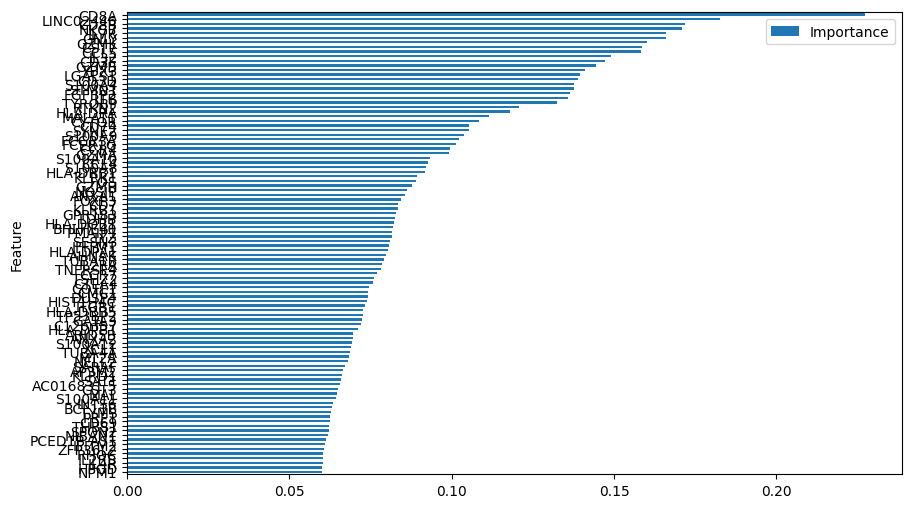

In [6]:
import numpy as np
import pandas as pd

coefficients = model.coef_

avg_importance = np.mean(np.abs(coefficients), axis=0)
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': avg_importance})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.to_pickle("feature_importance_logisticregression_10_000_genes.pkl")
feature_importance = feature_importance.iloc[-100:]
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))

In [7]:
# with StandardScaler
from sklearn.preprocessing import StandardScaler

if hasattr(X_train, "toarray"):
    X_train = X_train.toarray()
if hasattr(X_test, "toarray"):
    X_test = X_test.toarray()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

model = LogisticRegression(C=0.3520083597327549, 
                           class_weight=None, 
                           penalty='l1', 
                           tol=0.008814807410979418, 
                           solver='saga', 
                           max_iter=1000
                          )
model.fit(X_train_scaled, y_train)

print(model.score(X_test_scaled, y_test))
y_pred = model.predict(X_test_scaled)
print(f"Macro F1: {f1_score(y_test, y_pred, average="macro")}")

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


0.9066417418077853
Macro F1: 0.7843370852693642


### Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(max_depth=30,
                               max_features='sqrt',
                               n_estimators=100
                              )
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.7576424015834616


In [2]:
# Optimal Hyperparameter for scumi-annotated labels
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(max_depth=26,
                               max_features='sqrt',
                               n_estimators=151
                              )
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.8734803657880581


In [3]:
import pickle

with open("models/randomforest_scumi_annotated.pkl", "wb") as f:
    pickle.dump(model, f)

In [4]:
import pandas as pd

importances = model.feature_importances_
feature_names = X_train.columns

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance = feature_importance.sort_values('Importance', ascending=True)

feature_importance.to_pickle("feature_importance_randomforest_10_000_genes_scumi_annotated.pkl")

### ExtraTrees

In [4]:
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier(max_depth=28,
                               max_features='sqrt',
                               n_estimators=249
                              )
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.7525551371705218


In [7]:
# Optimal Hyperparameter for scumi-annotated labels
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier(max_depth=28,
                               max_features='sqrt',
                               n_estimators=250
                              )
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.877891339429801


In [8]:
import pickle

with open("models/extratrees_scumi_annotated.pkl", "wb") as f:
    pickle.dump(model, f)

### XGBoost

In [ ]:
import pandas as pd

y_train_series = pd.Series(y_train)

min_samples = 5
class_counts = y_train_series.value_counts()
valid_classes = class_counts[class_counts >= min_samples].index

train_mask = y_train_series.isin(valid_classes).values
X_train = X_train[train_mask]
y_train = y_train_series[train_mask]

In [3]:
from sklearn.preprocessing import LabelEncoder

## Encode Labels
le_train = LabelEncoder()
y_train_enc = le_train.fit_transform(y_train.to_numpy() if hasattr(y_train, 'to_numpy') else y_train)

classes_in_train = set(y_train)
mask = y_test.isin(classes_in_train).values

X_test_filtered = X_test[mask]
y_test_filtered = y_test[mask]

y_test_enc = le_train.transform(y_test_filtered.to_numpy() if hasattr(y_test_filtered, 'to_numpy') else y_test_filtered)
X_test = X_test_filtered.to_numpy() if hasattr(X_test_filtered, 'to_numpy') else X_test_filtered

num_classes = len(le_train.classes_)

In [4]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Modell
model = XGBClassifier(colsample_bytree=0.3243971814938379,
                      learning_rate=0.17281917047417422,
                      max_depth=5
                     )

model.fit(X_train, y_train_enc)

print(model.score(X_test, y_test_enc))

0.8848308554190907


In [5]:
import pickle

with open("models/xgboost.pkl", "wb") as f:
    pickle.dump(model, f)

### LightGBM

In [9]:
import lightgbm as lgbm

#modelLGBM = LGBMClassifier(boosting_type='dart', learning_rate=0.03752055855124281, 
#                           max_depth=10, n_estimators=444, num_leaves=36, verbose=0)
modelLGBM = lgbm.LGBMClassifier(objective='multiclass')
modelLGBM.fit(X_train, y_train)

print(modelLGBM.score(X_test, y_test))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.232055 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 778851
[LightGBM] [Info] Number of data points in the train set: 18325, number of used features: 6370
[LightGBM] [Info] Start training from score -6.925650
[LightGBM] [Info] Start training from score -9.816022
[LightGBM] [Info] Start training from score -1.714344
[LightGBM] [Info] Start training from score -8.024262
[LightGBM] [Info] Start training from score -4.595666
[LightGBM] [Info] Start training from score -7.176964
[LightGBM] [Info] Start training from score -5.231054
[LightGBM] [Info] Start training from score -9.816022
[LightGBM] [Info] Start training from score -7.418126
[LightGBM] [Info] Start training from score -8.024262
[LightGBM] [Info] Start training from score -5.350113
[LightGBM] [Info] Start training from score -4.468914
[LightGBM] [Info] Start training from score -6.771499
[Ligh

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [9]:
# Optimal Hyperparameter for scumi-annotated labels
import lightgbm as lgbm

modelLGBM = lgbm.LGBMClassifier(objective='multiclass',
                                feature_fraction=0.6763225686917771,
                                learning_rate=0.031197042137161936,
                                n_estimators=50,
                                num_leaves=91
                               )
modelLGBM.fit(X_train, y_train)

print(modelLGBM.score(X_test, y_test))

[LightGBM] [Warning] feature_fraction is set=0.6763225686917771, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6763225686917771
[LightGBM] [Warning] feature_fraction is set=0.6763225686917771, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6763225686917771
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.238460 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 778851
[LightGBM] [Info] Number of data points in the train set: 18325, number of used features: 6370
[LightGBM] [Info] Start training from score -4.199250
[LightGBM] [Info] Start training from score -1.546777
[LightGBM] [Info] Start training from score -0.659187
[LightGBM] [Info] Start training from score -3.049830
[LightGBM] [Info] Start training from score -4.628636
[LightGBM] [Info] Start training from score -4.247677
[LightGBM] [Info] Start training from score -1.713435
[LightGBM] [Info] Sta

In [10]:
import pickle

with open("models/lightgbm_scumi_annotated.pkl", "wb") as f:
    pickle.dump(model, f)

### LinearSVC

In [2]:
from sklearn.svm import LinearSVC

{'C': 0.05907694609979313, 'class_weight': None, 'penalty': 'l1', 'tol': 0.0004717746164106244}
model = LinearSVC(C=0.05907694609979313, 
                           class_weight=None, 
                           penalty='l1', 
                           tol=0.0004717746164106244
                          )
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.8979020979020979


C:\Users\Julian Kraus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [5]:
# Optimal Hyperparameter for scumi-annotated labels
from sklearn.svm import LinearSVC

model = LinearSVC(C=0.004240705571724369, 
                           dual=False, 
                           penalty='l1', 
                           tol=0.009170815634047421
                          )
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.9525551371705218


In [6]:
import pickle

with open("models/linearsvc_scumi_annotated.pkl", "wb") as f:
    pickle.dump(model, f)

### Voting Classifier

In [9]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import lightgbm as lgbm

# Basismodelle definieren
# RandomForest
modelRF = RandomForestClassifier(max_depth=30, max_features='sqrt', n_estimators=100)

# ExtraTrees
modelET = ExtraTreesClassifier(max_depth=28, max_features='sqrt', n_estimators=249)

# Support Vector Machine
modelSVM = LinearSVC(C=0.05907694609979313, class_weight=None, penalty='l1', tol=0.0004717746164106244)

# GradientBoosting
modelXGB = XGBClassifier(colsample_bytree=0.3243971814938379, learning_rate=0.17281917047417422, max_depth=5)

# LogisticRegression
modelLR = LogisticRegression(C=0.3520083597327549, class_weight=None, penalty='l1', tol=0.008814807410979418, solver='saga', max_iter=1000)

# LightGBM
modelLGBM = lgbm.LGBMClassifier(objective='multiclass')

# KNeighbours
modelKNN1 = KNeighborsClassifier(n_neighbors=10)
modelKNN2 = KNeighborsClassifier(n_neighbors=10, weights='uniform', leaf_size=5, p=2)

# Voting Classifier erstellen
voting_clf = VotingClassifier(estimators=[('rf', modelRF), ('lr', modelLR),
                                          ('svc', modelSVM), ('et', modelET)],
                              voting='hard')  # 'soft' Voting bedeutet, dass Wahrscheinlichkeiten verwendet werden
#, ('rd', modelRD), ('bc', modelBC)

voting_clf.fit(X_train, y_train)

# Modell evaluieren
accuracy = voting_clf.score(X_test, y_test)
print(f"Voting Classifier Accuracy: {accuracy}")


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Voting Classifier Accuracy: 0.7918235610543303


In [10]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import lightgbm as lgbm

# Basismodelle definieren
# RandomForest
modelRF = RandomForestClassifier(max_depth=30, max_features='sqrt', n_estimators=100)

# ExtraTrees
modelET = ExtraTreesClassifier(max_depth=28, max_features='sqrt', n_estimators=249)

# Support Vector Machine
modelSVM = LinearSVC(C=0.05907694609979313, class_weight=None, penalty='l1')

# GradientBoosting
modelXGB = XGBClassifier(colsample_bytree=0.3243971814938379, learning_rate=0.17281917047417422, max_depth=5)

# LogisticRegression
modelLR = LogisticRegression(class_weight=None, penalty='l1', solver='saga', max_iter=1000)

# LightGBM
modelLGBM = lgbm.LGBMClassifier(objective='multiclass')

# KNeighbours
modelKNN1 = KNeighborsClassifier(n_neighbors=10)
modelKNN2 = KNeighborsClassifier(n_neighbors=10, weights='uniform', leaf_size=5, p=2)

# Voting Classifier erstellen
voting_clf = VotingClassifier(estimators=[('rf', modelRF), ('lr', modelLR),
                                          ('svc', modelSVM), ('et', modelET)],
                              voting='hard')  # 'soft' Voting bedeutet, dass Wahrscheinlichkeiten verwendet werden
#, ('rd', modelRD), ('bc', modelBC)

voting_clf.fit(X_train, y_train)

# Modell evaluieren
accuracy = voting_clf.score(X_test, y_test)
print(f"Voting Classifier Accuracy: {accuracy}")


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn

Voting Classifier Accuracy: 0.7944055944055944


In [11]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier

# RandomForest
modelRF = RandomForestClassifier(max_depth=30, max_features='sqrt', n_estimators=100)

# ExtraTrees
modelET = ExtraTreesClassifier(max_depth=28, max_features='sqrt', n_estimators=249)

# Support Vector Machine
modelSVM = LinearSVC(C=0.05907694609979313, class_weight=None, penalty='l1')

# GradientBoosting
modelXGB = XGBClassifier(colsample_bytree=0.3243971814938379, learning_rate=0.17281917047417422, max_depth=5)

# LogisticRegression
modelLR = LogisticRegression(class_weight=None, penalty='l1', solver='saga', max_iter=1000)

# LightGBM
modelLGBM = lgbm.LGBMClassifier(objective='multiclass')

# KNeighbours
modelKNN1 = KNeighborsClassifier(n_neighbors=10)
modelKNN2 = KNeighborsClassifier(n_neighbors=10, weights='uniform', leaf_size=5, p=2)

# Basismodelle definieren
all_models = {
    'rf': RandomForestClassifier(max_depth=30, max_features='sqrt', n_estimators=100),
    'et': ExtraTreesClassifier(max_depth=28, max_features='sqrt', n_estimators=249),
    'xgb': XGBClassifier(colsample_bytree=0.3243971814938379, learning_rate=0.17281917047417422, max_depth=5),
    'lr': LogisticRegression(class_weight=None, penalty='l1', solver='saga', max_iter=1000),
    'svc': LinearSVC(C=0.05907694609979313, class_weight=None, penalty='l1'),
    'linsvc': CalibratedClassifierCV(LinearSVC(C=0.05907694609979313, class_weight=None, penalty='l1'), cv=5),
    'knn': KNeighborsClassifier(n_neighbors=10),
    'lgbm': lgbm.LGBMClassifier(objective='multiclass'),
}

# Modellkombinationen definieren
model_sets = [
    ['rf', 'et', 'lr'],
    ['rf', 'linsvc', 'lr'],
    ['et', 'linsvc', 'lr'],
    ['rf', 'linsvc', 'et', 'lr'],
    ['rf', 'linsvc', 'et', 'lr', 'lgbm']
]

# Ergebnisse speichern
results = []

# Trainingsdaten (ersetzen mit deinen Daten)
X = X_train
y = y_train

# Schleife über Sets und Voting-Typen
for i, model_names in enumerate(model_sets):
    for voting_type in ['hard', 'soft']:
        try:
            estimators = [(name, all_models[name]) for name in model_names]

            # Für 'soft' Voting: prüfe, ob alle Modelle 'predict_proba' unterstützen
            if voting_type == 'soft':
                incompatible_models = [name for name, model in estimators if not hasattr(model, "predict_proba")]
                if incompatible_models:
                    print(f"Set {i+1} mit {voting_type} voting übersprungen – inkompatible Modelle: {incompatible_models}")
                    continue

            # Voting Classifier
            voting_clf = VotingClassifier(estimators=estimators, voting=voting_type)

            # 5-fache Cross-Validation
            scores = cross_val_score(voting_clf, X, y, cv=5)
            avg_score = np.mean(scores)
            results.append((model_names, voting_type, avg_score))

            print(f"Set {i+1} | Voting: {voting_type} | Modelle: {model_names} -> Accuracy: {avg_score:.4f}")
        except Exception as e:
            print(f"Fehler bei Set {i+1} ({voting_type}): {e}")

# Beste Kombination anzeigen
best_set = max(results, key=lambda x: x[2])
print(f"\nBeste Kombination: {best_set[0]} mit Voting: {best_set[1]} → Accuracy: {best_set[2]:.4f}")

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.

Set 1 | Voting: hard | Modelle: ['rf', 'et', 'lr'] -> Accuracy: 0.8337


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.

KeyboardInterrupt: 

In [12]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier

# RandomForest
modelRF = RandomForestClassifier(max_depth=30, max_features='sqrt', n_estimators=100)

# ExtraTrees
modelET = ExtraTreesClassifier(max_depth=28, max_features='sqrt', n_estimators=249)

# Support Vector Machine
modelSVM = LinearSVC(C=0.05907694609979313, class_weight=None, penalty='l1')

# GradientBoosting
modelXGB = XGBClassifier(colsample_bytree=0.3243971814938379, learning_rate=0.17281917047417422, max_depth=5)

# LogisticRegression
modelLR = LogisticRegression(class_weight=None, penalty='l1', solver='saga', max_iter=1000)

# LightGBM
modelLGBM = lgbm.LGBMClassifier(objective='multiclass')

# KNeighbours
modelKNN1 = KNeighborsClassifier(n_neighbors=10)
modelKNN2 = KNeighborsClassifier(n_neighbors=10, weights='uniform', leaf_size=5, p=2)

# Basismodelle definieren
all_models = {
    'rf': RandomForestClassifier(max_depth=30, max_features='sqrt', n_estimators=100),
    'et': ExtraTreesClassifier(max_depth=28, max_features='sqrt', n_estimators=249),
    'xgb': XGBClassifier(colsample_bytree=0.3243971814938379, learning_rate=0.17281917047417422, max_depth=5),
    'lr': LogisticRegression(class_weight=None, penalty='l1', solver='saga', max_iter=1000),
    'linsvc': LinearSVC(C=0.05907694609979313, class_weight=None, penalty='l1'),
    'linsvccal': CalibratedClassifierCV(LinearSVC(C=0.05907694609979313, class_weight=None, penalty='l1'), cv=5),
    'knn': KNeighborsClassifier(n_neighbors=10),
    'lgbm': lgbm.LGBMClassifier(objective='multiclass'),
}

# Modellkombinationen definieren
model_sets = [
    ['rf', 'et', 'lr'],
    ['rf', 'linsvc', 'lr'],
    ['et', 'linsvc', 'lr'],
    ['rf', 'linsvc', 'et', 'lr'],
    ['rf', 'linsvc', 'et', 'lr', 'lgbm']
]

# Ergebnisse speichern
results = []

# Trainingsdaten (ersetzen mit deinen Daten)
X = X_train
y = y_train

# Schleife über Sets und Voting-Typen
for i, model_names in enumerate(model_sets):
    for voting_type in ['hard', 'soft']:
        try:
            estimators = [(name, all_models[name]) for name in model_names]

            # Für 'soft' Voting: prüfe, ob alle Modelle 'predict_proba' unterstützen
            if voting_type == 'soft':
                incompatible_models = [name for name, model in estimators if not hasattr(model, "predict_proba")]
                if incompatible_models:
                    print(f"Set {i+1} mit {voting_type} voting übersprungen – inkompatible Modelle: {incompatible_models}")
                    continue

            # Voting Classifier
            voting_clf = VotingClassifier(estimators=estimators, voting=voting_type)

            voting_clf.fit(X_train, y_train)

            # Modell evaluieren
            accuracy = voting_clf.score(X_test, y_test)
            results.append((model_names, voting_type, accuracy))

            print(f"Set {i+1} | Voting: {voting_type} | Modelle: {model_names} -> Accuracy: {avg_score:.4f}")
        except Exception as e:
            print(f"Fehler bei Set {i+1} ({voting_type}): {e}")

# Beste Kombination anzeigen
best_set = max(results, key=lambda x: x[2])
print(f"\nBeste Kombination: {best_set[0]} mit Voting: {best_set[1]} → Accuracy: {best_set[2]:.4f}")

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn

Set 1 | Voting: hard | Modelle: ['rf', 'et', 'lr'] -> Accuracy: 0.8337


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn

Set 1 | Voting: soft | Modelle: ['rf', 'et', 'lr'] -> Accuracy: 0.8337


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/hom

...

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/hom

Set 4 | Voting: hard | Modelle: ['rf', 'linsvc', 'et', 'lr'] -> Accuracy: 0.8337
Set 4 mit soft voting übersprungen – inkompatible Modelle: ['linsvc']


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/hom

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.222274 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 778851
[LightGBM] [Info] Number of data points in the train set: 18325, number of used features: 6370
[LightGBM] [Info] Start training from score -6.925650
[LightGBM] [Info] Start training from score -9.816022
[LightGBM] [Info] Start training from score -1.714344
[LightGBM] [Info] Start training from score -8.024262
[LightGBM] [Info] Start training from score -4.595666
[LightGBM] [Info] Start training from score -7.176964
[LightGBM] [Info] Start training from score -5.231054
[LightGBM] [Info] Start training from score -9.816022
[LightGBM] [Info] Start training from score -7.418126
[LightGBM] [Info] Start training from score -8.024262
[LightGBM] [Info] Start training from score -5.350113
[LightGBM] [Info] Start training from score -4.468914
[LightGBM] [Info] Start training from score -6.771499
[Ligh

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
i=1
for result in results:
    print(f"Set {i} | Voting: {result[1]} | Modelle: {result[0]} -> Accuracy: {result[2]:.4f}")
    i += 1

Set 1 | Voting: hard | Modelle: ['rf', 'et', 'lr'] -> Accuracy: 0.7689
Set 2 | Voting: soft | Modelle: ['rf', 'et', 'lr'] -> Accuracy: 0.8939
Set 3 | Voting: hard | Modelle: ['rf', 'linsvc', 'lr'] -> Accuracy: 0.8965
Set 4 | Voting: hard | Modelle: ['et', 'linsvc', 'lr'] -> Accuracy: 0.8956
Set 5 | Voting: hard | Modelle: ['rf', 'linsvc', 'et', 'lr'] -> Accuracy: 0.7914
Set 6 | Voting: hard | Modelle: ['rf', 'linsvc', 'et', 'lr', 'lgbm'] -> Accuracy: 0.7806


In [17]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings("ignore")  # Optional: reduziert Ausgaben

# RandomForest
modelRF = RandomForestClassifier(max_depth=30, max_features='sqrt', n_estimators=100)

# ExtraTrees
modelET = ExtraTreesClassifier(max_depth=28, max_features='sqrt', n_estimators=249)

# Support Vector Machine
modelSVM = LinearSVC(C=0.05907694609979313, class_weight=None, penalty='l1')

# GradientBoosting
modelXGB = XGBClassifier(colsample_bytree=0.3243971814938379, learning_rate=0.17281917047417422, max_depth=5)

# LogisticRegression
modelLR = LogisticRegression(class_weight=None, penalty='l1', solver='saga', max_iter=1000)

# LightGBM
modelLGBM = lgbm.LGBMClassifier(objective='multiclass')

# KNeighbours
modelKNN1 = KNeighborsClassifier(n_neighbors=10)
modelKNN2 = KNeighborsClassifier(n_neighbors=10, weights='uniform', leaf_size=5, p=2)

# Basismodelle definieren
all_models = {
    'rf': RandomForestClassifier(max_depth=30),
    'et': ExtraTreesClassifier(max_depth=28),
    'xgb': XGBClassifier(colsample_bytree=0.3243971814938379, learning_rate=0.17281917047417422, max_depth=5),
    'lr': LogisticRegression(penalty='l1', solver='saga', max_iter=1000),
    'linsvc': LinearSVC(penalty='l1'),
    'linsvccal': CalibratedClassifierCV(LinearSVC(penalty='l1'), cv=5),
    'knn': KNeighborsClassifier(n_neighbors=10),
    'lgbm': lgbm.LGBMClassifier(objective='multiclass'),
}

# Modellkombinationen definieren
model_sets = [
    ['rf', 'et', 'lr'],
    ['rf', 'et', 'lr', 'knn'],
    ['rf', 'linsvc', 'lr'],
    ['rf', 'linsvc', 'lr', 'knn'],
    ['et', 'linsvc', 'lr'],
    ['et', 'linsvc', 'lr', 'knn']
]

# Ergebnisse speichern
results = []

# Trainingsdaten (ersetzen mit deinen Daten)
X = X_train
y = y_train

# Schleife über Sets und Voting-Typen
for i, model_names in enumerate(model_sets):
    for voting_type in ['hard', 'soft']:
        if i==0 and voting_type=='hard':
            continue
        
        try:
            estimators = [(name, all_models[name]) for name in model_names]

            # Für 'soft' Voting: prüfe, ob alle Modelle 'predict_proba' unterstützen
            if voting_type == 'soft':
                incompatible_models = [name for name, model in estimators if not hasattr(model, "predict_proba")]
                if incompatible_models:
                    print(f"Set {i+1} mit {voting_type} voting übersprungen – inkompatible Modelle: {incompatible_models}")
                    continue

            # Voting Classifier
            voting_clf = VotingClassifier(estimators=estimators, voting=voting_type)

            voting_clf.fit(X_train, y_train)

            # Modell evaluieren
            accuracy = voting_clf.score(X_test, y_test)
            results.append((model_names, voting_type, accuracy))

            print(f"Set {i+1} | Voting: {voting_type} | Modelle: {model_names} -> Accuracy: {accuracy:.4f}")
        except Exception as e:
            print(f"Fehler bei Set {i+1} ({voting_type}): {e}")

# Beste Kombination anzeigen
best_set = max(results, key=lambda x: x[2])
print(f"\nBeste Kombination: {best_set[0]} mit Voting: {best_set[1]} → Accuracy: {best_set[2]:.4f}")

Set 1 | Voting: soft | Modelle: ['rf', 'et', 'lr'] -> Accuracy: 0.8927
Set 2 | Voting: hard | Modelle: ['rf', 'et', 'lr', 'knn'] -> Accuracy: 0.7698
Set 2 | Voting: soft | Modelle: ['rf', 'et', 'lr', 'knn'] -> Accuracy: 0.8810
Set 3 | Voting: hard | Modelle: ['rf', 'linsvc', 'lr'] -> Accuracy: 0.8896
Set 3 mit soft voting übersprungen – inkompatible Modelle: ['linsvc']
Set 4 | Voting: hard | Modelle: ['rf', 'linsvc', 'lr', 'knn'] -> Accuracy: 0.8860
Set 4 mit soft voting übersprungen – inkompatible Modelle: ['linsvc']
Set 5 | Voting: hard | Modelle: ['et', 'linsvc', 'lr'] -> Accuracy: 0.8874
Set 5 mit soft voting übersprungen – inkompatible Modelle: ['linsvc']
Set 6 | Voting: hard | Modelle: ['et', 'linsvc', 'lr', 'knn'] -> Accuracy: 0.8828
Set 6 mit soft voting übersprungen – inkompatible Modelle: ['linsvc']

Beste Kombination: ['rf', 'et', 'lr'] mit Voting: soft → Accuracy: 0.8927


In [18]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import lightgbm as lgbm

# Basismodelle definieren
# RandomForest
modelRF = RandomForestClassifier(max_depth=30, max_features='sqrt', n_estimators=100)

# ExtraTrees
modelET = ExtraTreesClassifier(max_depth=28, max_features='sqrt', n_estimators=249)

# Support Vector Machine
modelSVM = LinearSVC(C=0.05907694609979313, class_weight=None, penalty='l1', tol=0.0004717746164106244)

# GradientBoosting
modelXGB = XGBClassifier(colsample_bytree=0.3243971814938379, learning_rate=0.17281917047417422, max_depth=5)

# LogisticRegression
modelLR = LogisticRegression(C=0.3520083597327549, class_weight=None, penalty='l1', tol=0.008814807410979418, solver='saga', max_iter=1000)

# LightGBM
modelLGBM = lgbm.LGBMClassifier(objective='multiclass')

# KNeighbours
modelKNN1 = KNeighborsClassifier(n_neighbors=10)
modelKNN2 = KNeighborsClassifier(n_neighbors=10, weights='uniform', leaf_size=5, p=2)

# Voting Classifier erstellen
voting_clf = VotingClassifier(estimators=[('rf', modelRF), ('lr', modelLR),
                                          ('svc', modelSVM)], #, ('et', modelET)
                              voting='hard')

voting_clf.fit(X_train, y_train)

# Modell evaluieren
accuracy = voting_clf.score(X_test, y_test)
print(f"Voting Classifier Accuracy: {accuracy}")

Voting Classifier Accuracy: 0.8993006993006993


In [19]:
import pickle

with open("models/votingclassifier.pkl", "wb") as f:
    pickle.dump(voting_clf, f)

### StackingClassifier

In [2]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import lightgbm as lgbm

# Basismodelle definieren
# RandomForest
modelRF = RandomForestClassifier(max_depth=30, max_features='sqrt', n_estimators=100)

# ExtraTrees
modelET = ExtraTreesClassifier(max_depth=28, max_features='sqrt', n_estimators=249)

# Support Vector Machine
modelSVM = LinearSVC(C=0.05907694609979313, class_weight=None, penalty='l1', tol=0.0004717746164106244)

# GradientBoosting
modelXGB = XGBClassifier(colsample_bytree=0.3243971814938379, learning_rate=0.17281917047417422, max_depth=5)

# LogisticRegression
modelLR = LogisticRegression(C=0.3520083597327549, class_weight=None, penalty='l1', tol=0.008814807410979418, solver='saga', max_iter=1000)

# LightGBM
modelLGBM = lgbm.LGBMClassifier(objective='multiclass')

# KNeighbours
modelKNN1 = KNeighborsClassifier(n_neighbors=10)
modelKNN2 = KNeighborsClassifier(n_neighbors=10, weights='uniform', leaf_size=5, p=2)

# Basismodelle definieren
base_learners = [
    ('rf', modelRF),
    #('svc', modelSVM),
    ('lr', modelLR),
    #('gb', modelXGB1),
    ('lgbm', modelLGBM),
    #('knn', modelKNN1), 
]

# Meta-Classifier definieren
meta_learner = modelSVM#modelLR

# Stacking Classifier erstellen
stacking_clf = StackingClassifier(estimators=base_learners, final_estimator=meta_learner)

# Modell trainieren
stacking_clf.fit(X_train, y_train)

# Modell evaluieren
accuracy = stacking_clf.score(X_test, y_test)
print(f"Stacking Classifier Accuracy: {accuracy}")


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.221552 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 778851
[LightGBM] [Info] Number of data points in the train set: 18325, number of used features: 6370
[LightGBM] [Info] Start training from score -6.925650
[LightGBM] [Info] Start training from score -9.816022
[LightGBM] [Info] Start training from score -1.714344
[LightGBM] [Info] Start training from score -8.024262
[LightGBM] [Info] Start training from score -4.595666
[LightGBM] [Info] Start training from score -7.176964
[LightGBM] [Info] Start training from score -5.231054
[LightGBM] [Info] Start training from score -9.816022
[LightGBM] [Info] Start training from score -7.418126
[LightGBM] [Info] Start training from score -8.024262
[LightGBM] [Info] Start training from score -5.350113
[LightGBM] [Info] Start training from score -4.468914
[LightGBM] [Info] Start training from score -6.771499
[Ligh

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:1381: RuntimeWarning: Number of classes in training fold (34) does not match total number of classes (35). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:1381: RuntimeWarning: Number of classes in training fold (34) does not match total number of classes (35). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.209020 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 709471
[LightGBM] [Info] Number of data points in the train set: 14660, number of used features: 6041
[LightGBM] [Info] Start training from score -6.953821
[LightGBM] [Info] Start training from score -9.592878
[LightGBM] [Info] Start training from score -1.714344
[LightGBM] [Info] Start training from score -7.983440
[LightGBM] [Info] Start training from score -4.595666
[LightGBM] [Info] Start training from score -7.194983
[LightGBM] [Info] Start training from score -5.223430
[LightGBM] [Info] Start training from score -9.592878
[LightGBM] [Info] Start training from score -7.395653
[LightGBM] [Info] Start training from score -7.983440
[LightGBM] [Info] Start training from score -5.358771
[LightGBM] [Info] Start training from score -4.468914
[LightGBM] [Info] Start training from score -6.820289
[Ligh

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:1381: RuntimeWarning: Number of classes in training fold (34) does not match total number of classes (35). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.202421 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 729387
[LightGBM] [Info] Number of data points in the train set: 14660, number of used features: 6110
[LightGBM] [Info] Start training from score -6.953821
[LightGBM] [Info] Start training from score -1.714344
[LightGBM] [Info] Start training from score -7.983440
[LightGBM] [Info] Start training from score -4.595666
[LightGBM] [Info] Start training from score -7.194983
[LightGBM] [Info] Start training from score -5.236169
[LightGBM] [Info] Start training from score -9.592878
[LightGBM] [Info] Start training from score -7.513436
[LightGBM] [Info] Start training from score -7.983440
[LightGBM] [Info] Start training from score -5.358771
[LightGBM] [Info] Start training from score -4.468914
[LightGBM] [Info] Start training from score -6.759665
[LightGBM] [Info] Start training from score -4.764564
[Ligh

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:1381: RuntimeWarning: Number of classes in training fold (34) does not match total number of classes (35). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(


Stacking Classifier Accuracy: 0.9013448090371168


/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
Stacking Classifier Accuracy: 0.9026358257127488

In [3]:
import pickle

with open("models/stackingclassifier.pkl", "wb") as f:
    pickle.dump(stacking_clf, f)

In [24]:
# Basismodelle definieren
base_learners = [
    ('rf', modelRF),
    ('svc', modelSVM),
    #('lr', modelLR),
    #('gb', modelXGB1),
    ('lgbm', modelLGBM),
    #('knn', modelKNN1), 
]

# Meta-Classifier definieren
meta_learner = modelLR#modelSVM

# Stacking Classifier erstellen
stacking_clf = StackingClassifier(estimators=base_learners, final_estimator=meta_learner)

# Modell trainieren
stacking_clf.fit(X_train, y_train)

# Modell evaluieren
accuracy = stacking_clf.score(X_test, y_test)
print(f"Stacking Classifier Accuracy: {accuracy}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.272960 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 778851
[LightGBM] [Info] Number of data points in the train set: 18325, number of used features: 6370
[LightGBM] [Info] Start training from score -6.925650
[LightGBM] [Info] Start training from score -9.816022
[LightGBM] [Info] Start training from score -1.714344
[LightGBM] [Info] Start training from score -8.024262
[LightGBM] [Info] Start training from score -4.595666
[LightGBM] [Info] Start training from score -7.176964
[LightGBM] [Info] Start training from score -5.231054
[LightGBM] [Info] Start training from score -9.816022
[LightGBM] [Info] Start training from score -7.418126
[LightGBM] [Info] Start training from score -8.024262
[LightGBM] [Info] Start training from score -5.350113
[LightGBM] [Info] Start training from score -4.468914
[LightGBM] [Info] Start training from score -6.771499
[Ligh

In [25]:
import pickle

with open("models/stackingclassifier_bad.pkl", "wb") as f:
    pickle.dump(stacking_clf, f)